# ECoG-CNN correspondence

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
_c = load_cache('02_electrode_characterization')
electrode_type_df = _c['electrode_type_df']

_c = load_cache('03_ecog_rdms_baseline_similarity')
ecog_group_rdms = _c['ecog_group_rdms']

_c = load_cache('04_sliding_window_time_noise')
subject_epoch_cache = _c['subject_epoch_cache']

_c = load_cache('05_cnn_representations')
cnn_layer_rdms_primary = _c['cnn_layer_rdms_primary']


In [4]:
build_group_rdm_windowed = lambda s, g, lo, hi, **kw: ec.build_group_rdm_windowed(
    subject_epoch_cache, electrode_type_df, s, g, lo, hi, **kw)
layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))


Built 140 (subject x group x layer) comparisons; valid: 133


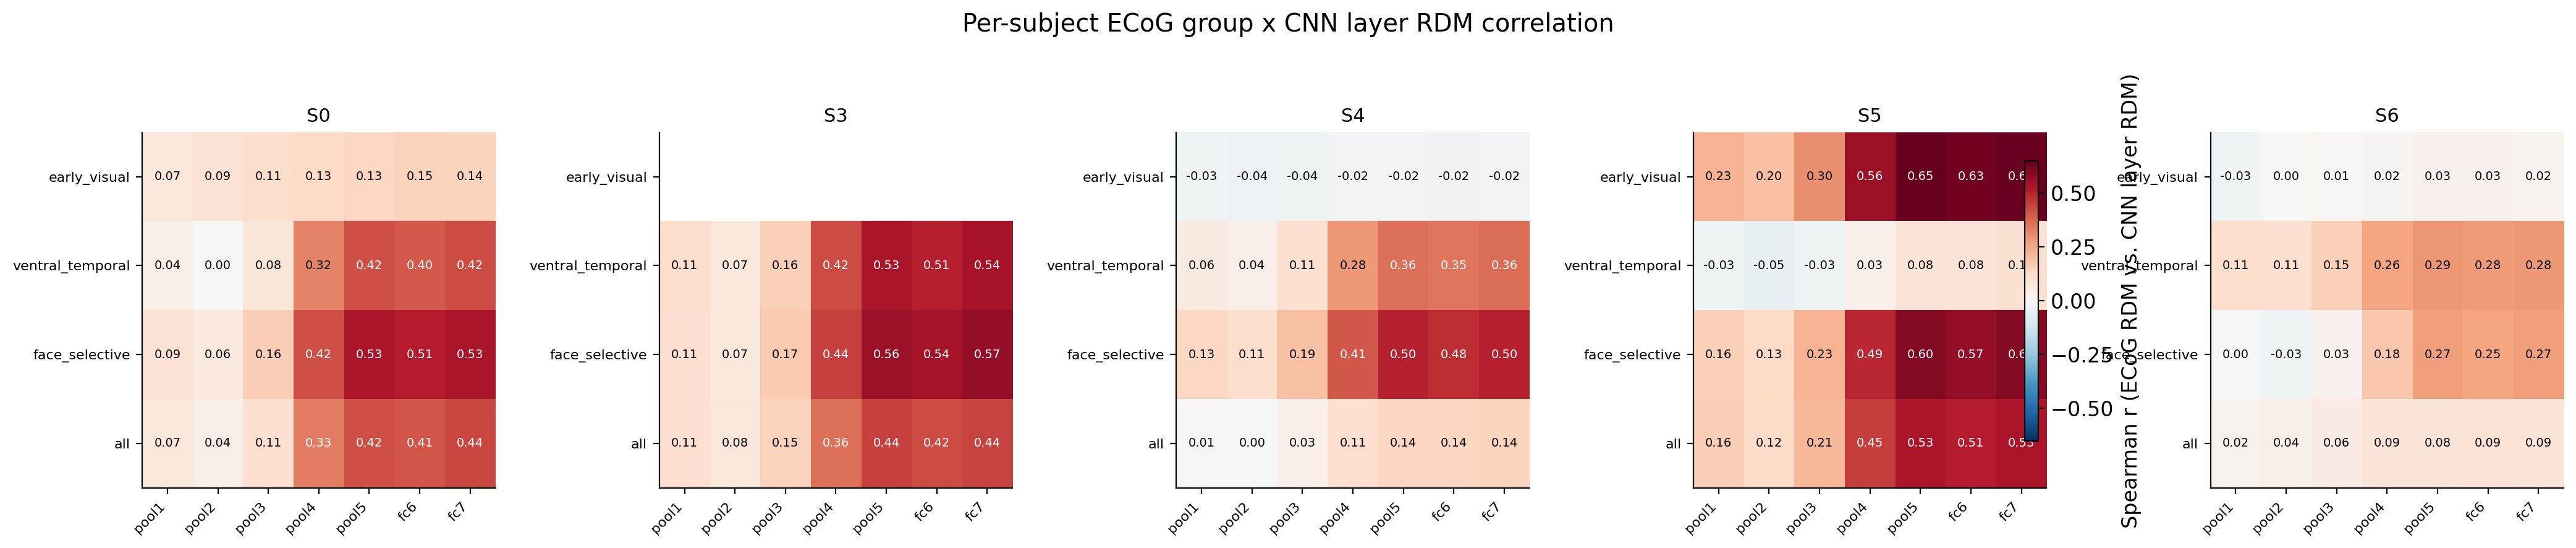

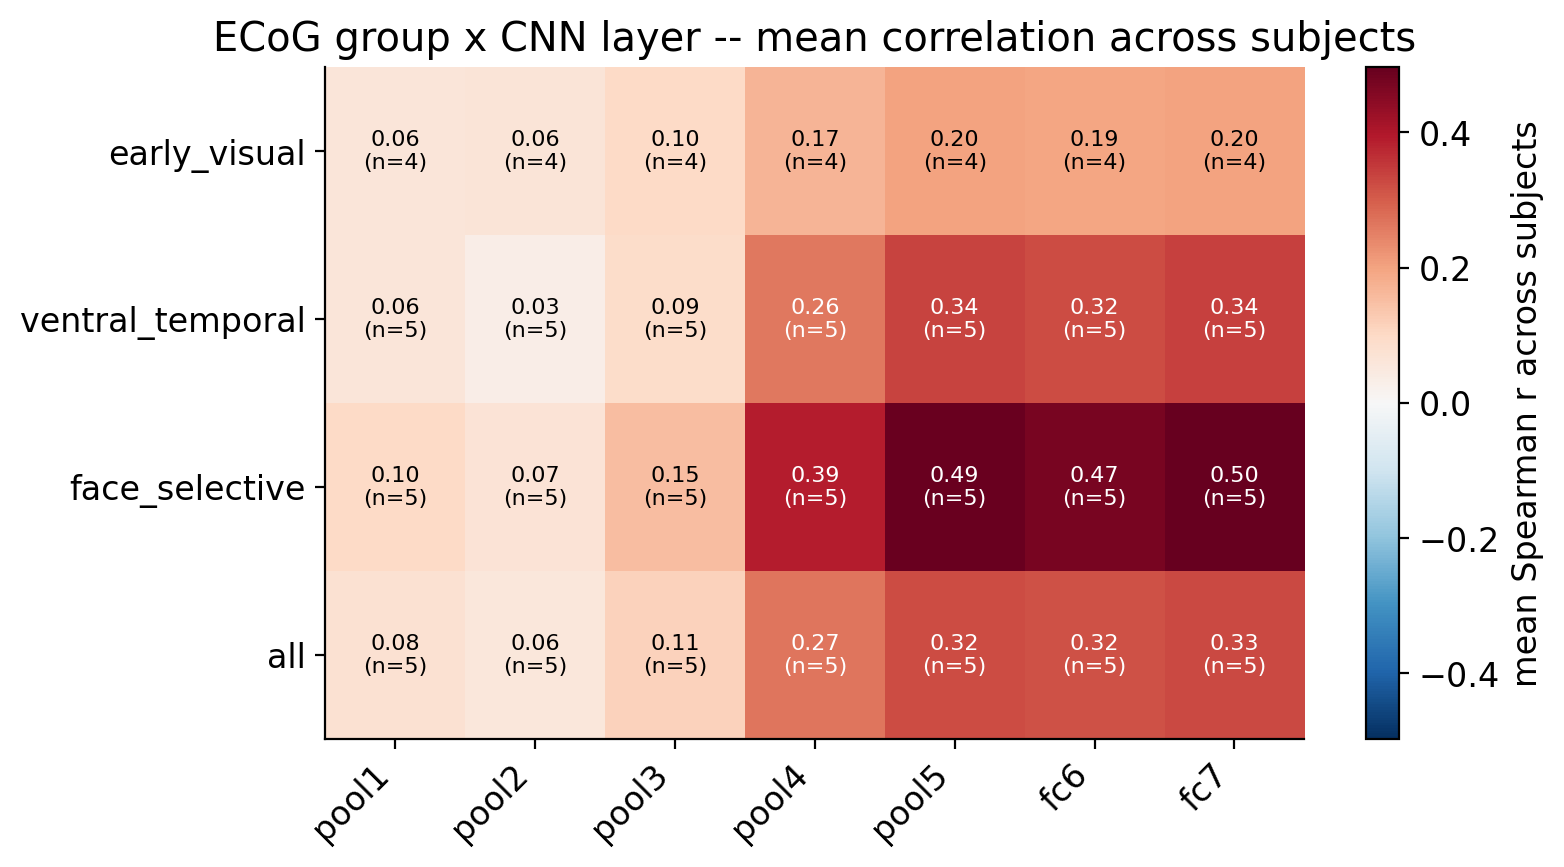

Subject-averaged Spearman r, group x layer (n = number of subjects contributing):
layer             pool1  pool2  pool3  pool4  pool5    fc6    fc7
group                                                            
early_visual      0.060  0.064  0.098  0.170  0.200  0.195  0.199
ventral_temporal  0.059  0.033  0.093  0.264  0.335  0.324  0.340
face_selective    0.099  0.069  0.154  0.388  0.492  0.473  0.496
all               0.075  0.056  0.113  0.267  0.324  0.316  0.328


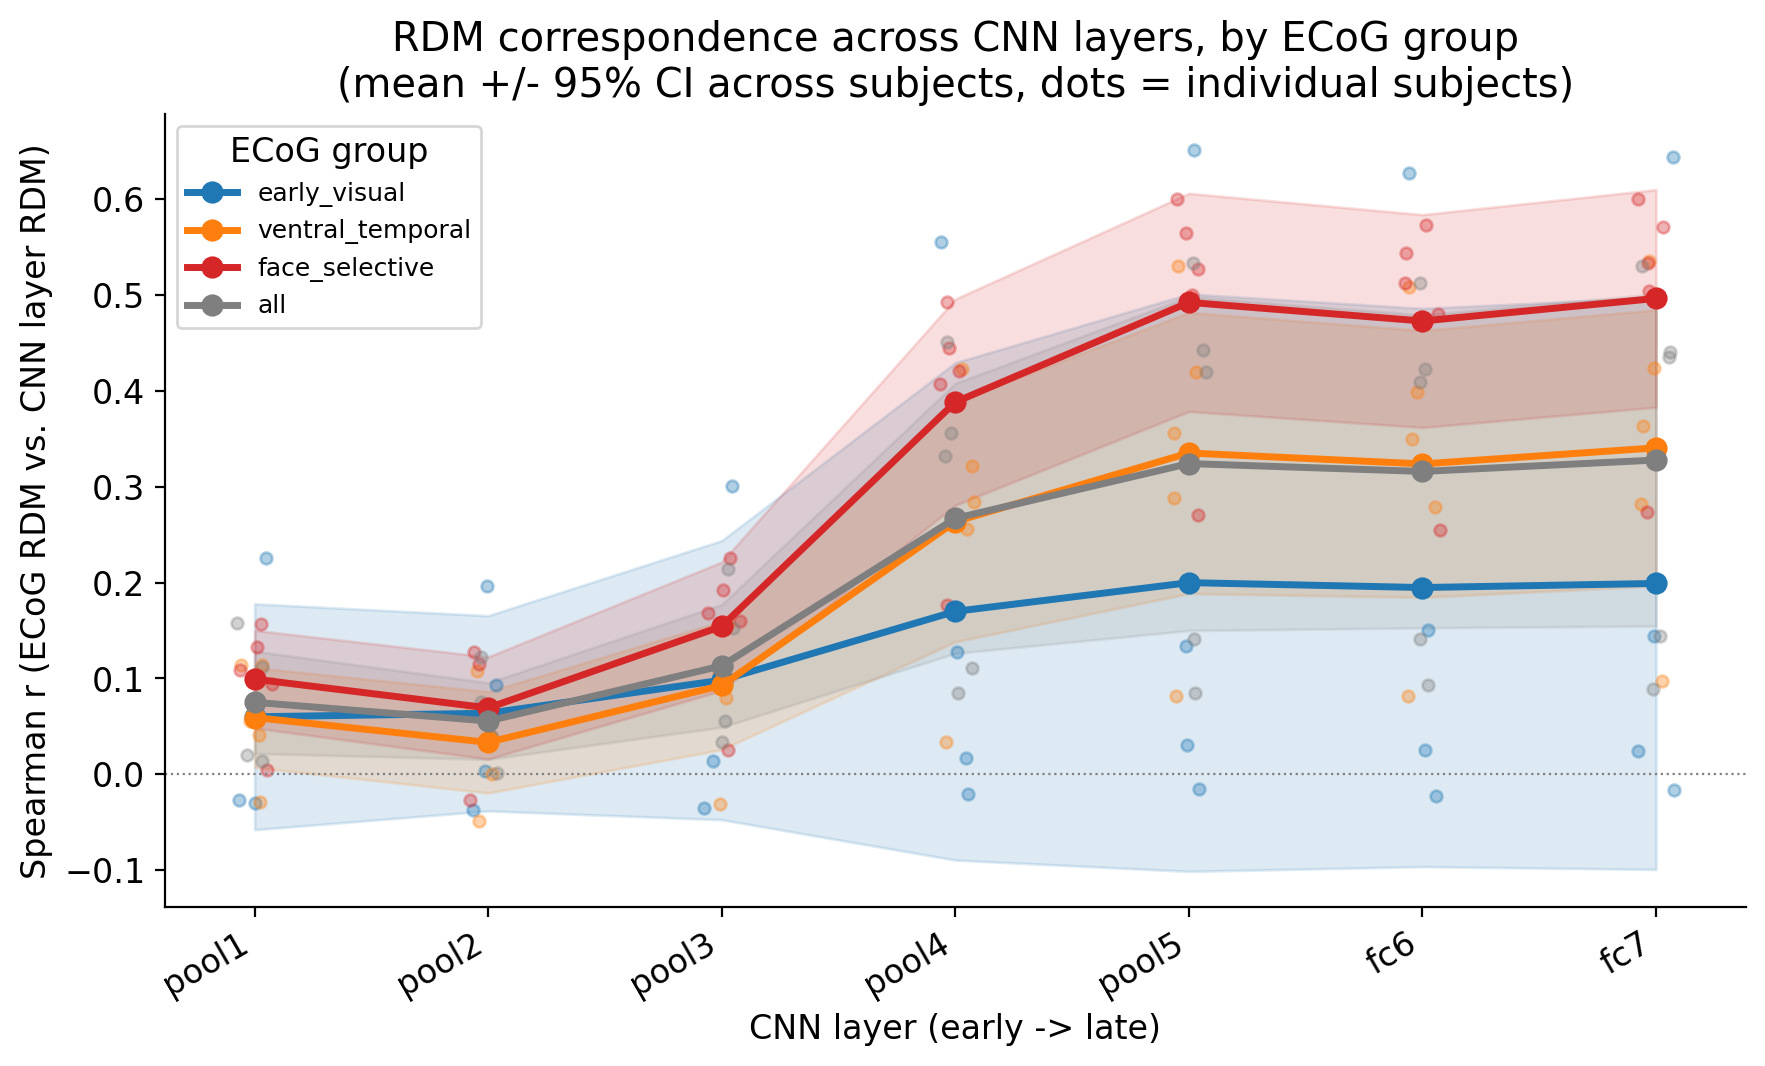

Mean Spearman r by group x layer:
layer             pool1  pool2  pool3  pool4  pool5    fc6    fc7
group                                                            
all               0.075  0.056  0.113  0.267  0.324  0.316  0.328
early_visual      0.060  0.064  0.098  0.170  0.200  0.195  0.199
face_selective    0.099  0.069  0.154  0.388  0.492  0.473  0.496
ventral_temporal  0.059  0.033  0.093  0.264  0.335  0.324  0.340


In [5]:
# @title Build subject x group x layer comparison table + heatmaps + layer-profile line plot

group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}

comparison_df = build_comparison_df(ecog_group_rdms, cnn_layer_rdms_primary, layer_names)
print(f"Built {len(comparison_df)} (subject x group x layer) comparisons; valid: {comparison_df['r'].notna().sum()}")

# per-subject heatmaps
fig, axes = plt.subplots(1, len(usable), figsize=(4.2*len(usable), 4.2))
vmax = np.nanmax(np.abs(comparison_df['r']))
for ax, s in zip(axes, usable):
    sub = comparison_df[comparison_df['subject'] == s]
    grid = sub.pivot(index='group', columns='layer', values='r').reindex(index=GROUP_NAMES, columns=layer_names)
    im = ax.imshow(grid.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(GROUP_NAMES))); ax.set_yticklabels(GROUP_NAMES, fontsize=8)
    ax.set_title(f'S{s}', fontsize=11)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                        color='white' if abs(val) > vmax*0.5 else 'black')
fig.colorbar(im, ax=axes, label='Spearman r (ECoG RDM vs. CNN layer RDM)', shrink=0.7, pad=0.02)
plt.suptitle('Per-subject ECoG group x CNN layer RDM correlation', y=1.05)
display(Image(save_fig(fig, '06_ecog_cnn_correspondence_fig01'))); plt.close(fig)

# subject-averaged heatmap: single group x layer grid, mean r across subjects (subject as random effect)
mean_df = comparison_df.groupby(['group', 'layer'], observed=True)['r'].agg(['mean', 'std', 'count']).reset_index()
grid_mean = mean_df.pivot(index='group', columns='layer', values='mean').reindex(index=GROUP_NAMES, columns=layer_names)
grid_n = mean_df.pivot(index='group', columns='layer', values='count').reindex(index=GROUP_NAMES, columns=layer_names)

fig, ax = plt.subplots(figsize=(8, 4.5))
vmax2 = np.nanmax(np.abs(grid_mean.values))
im = ax.imshow(grid_mean.values, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2, aspect='auto')
ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names, rotation=45, ha='right')
ax.set_yticks(range(len(GROUP_NAMES))); ax.set_yticklabels(GROUP_NAMES)
for i in range(grid_mean.shape[0]):
    for j in range(grid_mean.shape[1]):
        val, n = grid_mean.values[i, j], grid_n.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}\n(n={int(n)})', ha='center', va='center', fontsize=8,
                    color='white' if abs(val) > vmax2*0.5 else 'black')
fig.colorbar(im, ax=ax, label='mean Spearman r across subjects')
ax.set_title('ECoG group x CNN layer -- mean correlation across subjects')
plt.tight_layout(); display(Image(save_fig(fig, '06_ecog_cnn_correspondence_fig02'))); plt.close(fig)

print("Subject-averaged Spearman r, group x layer (n = number of subjects contributing):")
print(grid_mean.round(3))

# layer-profile line plot, mean +/- SEM across subjects, subject dots overlaid
layer_x = np.arange(len(layer_names))
fig, ax = plt.subplots(figsize=(9, 5.5))
rng_jitter = np.random.RandomState(0)
for group_name in GROUP_NAMES:
    sub = comparison_df[comparison_df['group'] == group_name]
    means = sub.groupby('layer', observed=True)['r'].mean().reindex(layer_names)
    sems = sub.groupby('layer', observed=True)['r'].sem().reindex(layer_names)
    c = group_colors.get(group_name, 'black')
    ax.plot(layer_x, means.values, 'o-', color=c, label=group_name, lw=2.5, markersize=7, zorder=3)
    ax.fill_between(layer_x, means.values - 1.96*sems.values, means.values + 1.96*sems.values, color=c, alpha=0.15)
    for s in usable:
        s_sub = sub[sub['subject'] == s].set_index('layer').reindex(layer_names)['r']
        jitter = rng_jitter.uniform(-0.08, 0.08, size=len(layer_x))
        ax.scatter(layer_x + jitter, s_sub.values, color=c, alpha=0.35, s=18, zorder=2)
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xticks(layer_x); ax.set_xticklabels(layer_names, rotation=30, ha='right')
ax.set_ylabel('Spearman r (ECoG RDM vs. CNN layer RDM)')
ax.set_xlabel('CNN layer (early -> late)')
ax.set_title('RDM correspondence across CNN layers, by ECoG group\n(mean +/- 95% CI across subjects, dots = individual subjects)')
ax.legend(title='ECoG group', fontsize=9)
plt.tight_layout(); display(Image(save_fig(fig, '06_ecog_cnn_correspondence_fig03'))); plt.close(fig)

print("Mean Spearman r by group x layer:")
print(comparison_df.groupby(['group', 'layer'], observed=True)['r'].mean().unstack().round(3))


Built 1197 rows; valid r: 1197


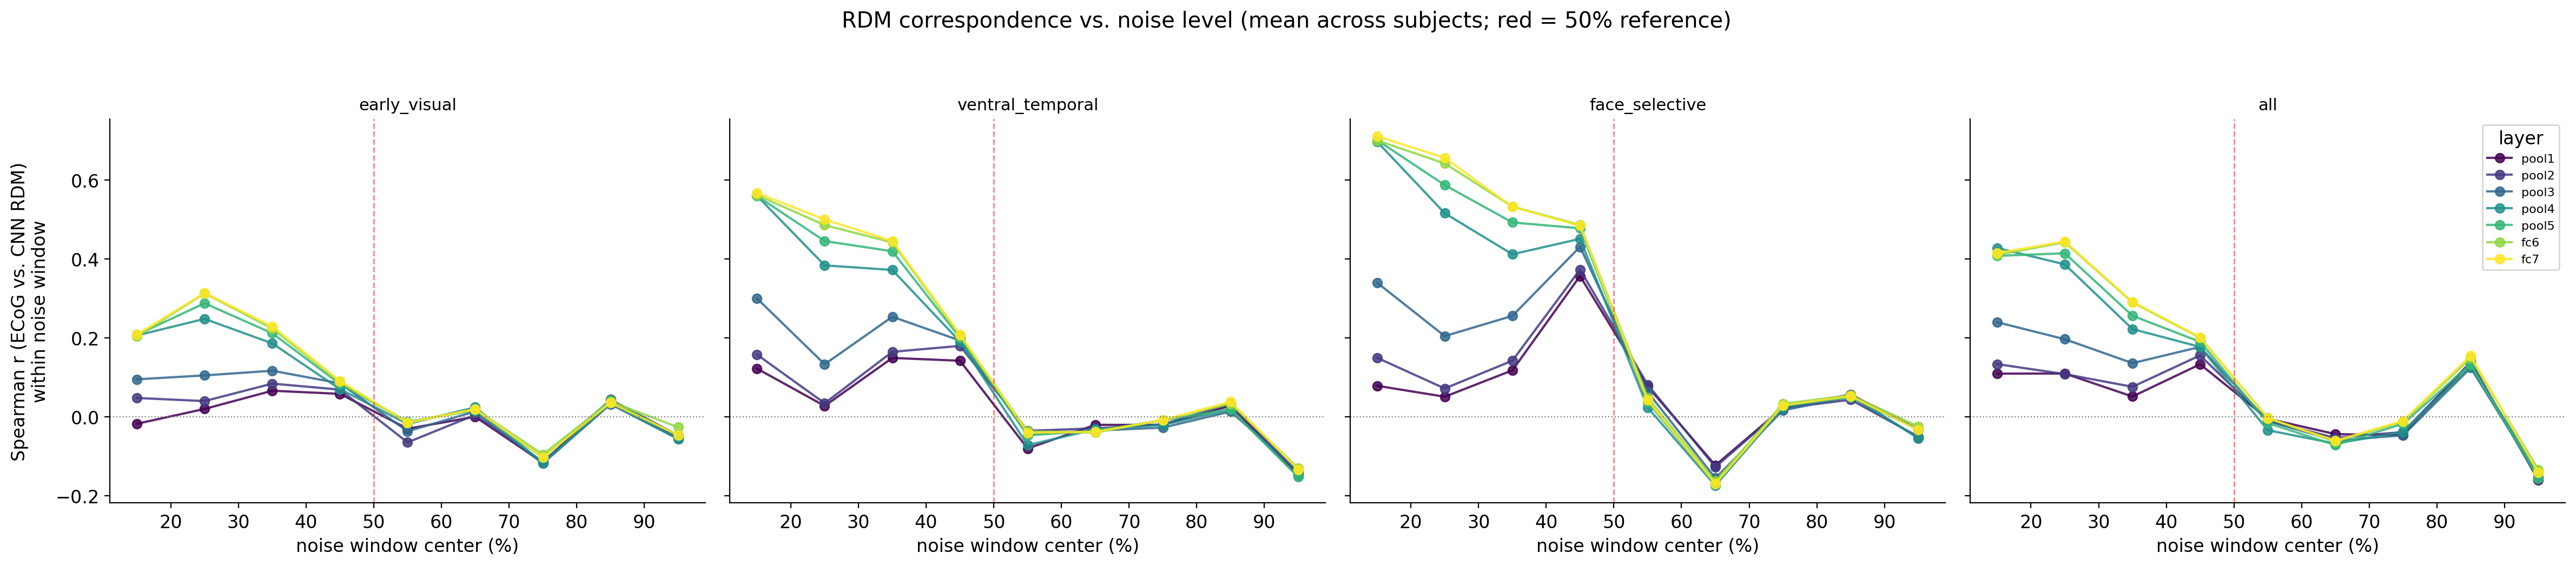


Noise window with peak correspondence, per group x layer:
layer             pool1  pool2  pool3  pool4  pool5   fc6   fc7
group                                                          
all                45.0   45.0   15.0   15.0   15.0  15.0  15.0
early_visual       85.0   85.0   45.0   25.0   25.0  25.0  25.0
face_selective     45.0   45.0   45.0   15.0   15.0  15.0  15.0
ventral_temporal   35.0   35.0   35.0   15.0   15.0  25.0  25.0


In [6]:
# @title Q2 -- ECoG-CNN correspondence within sliding 30%-wide noise windows

def get_noise_window_indices(center, width, noise_levels=NOISE_LEVELS):
    lo, hi = center - width/2, center + width/2
    levels_in_window = [n for n in noise_levels if lo <= n < hi]
    return [CONDITIONS.index(f'{cat}_{n}') for n in levels_in_window for cat in ['house', 'face']], levels_in_window

def subset_rdm(rdm, idx):
    return None if (rdm is None or len(idx) < 4) else rdm[np.ix_(idx, idx)]

NOISE_WIN_WIDTH, NOISE_WIN_STEP = 30, 10
noise_win_centers = np.arange(15, 101, NOISE_WIN_STEP)

q2_rows = []
for s in usable:
    for group_name in GROUP_NAMES:
        ecog_rdm = ecog_group_rdms.get((s, group_name))
        if ecog_rdm is None:
            continue
        for L in layer_names:
            cnn_rdm = cnn_layer_rdms_primary[L]
            for center in noise_win_centers:
                idx, levels = get_noise_window_indices(center, NOISE_WIN_WIDTH)
                r, p, n = compare_rdms(subset_rdm(ecog_rdm, idx), subset_rdm(cnn_rdm, idx))
                q2_rows.append(dict(subject=s, group=group_name, layer=L, noise_center=center, r=r, p=p, n_pairs=n))

q2_df = pd.DataFrame(q2_rows)
q2_df['layer'] = pd.Categorical(q2_df['layer'], categories=layer_names, ordered=True)
print(f"Built {len(q2_df)} rows; valid r: {q2_df['r'].notna().sum()}")

fig, axes = plt.subplots(1, len(GROUP_NAMES), figsize=(6*len(GROUP_NAMES), 5), sharey=True)
for ax, group_name in zip(axes, GROUP_NAMES):
    sub = q2_df[q2_df['group'] == group_name]
    for L, c in zip(layer_names, layer_colors):
        grp = sub[sub['layer'] == L].groupby('noise_center')['r'].mean()
        ax.plot(grp.index, grp.values, 'o-', color=c, label=L, alpha=0.85)
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.axvline(50, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_title(group_name, fontsize=11); ax.set_xlabel('noise window center (%)')
axes[0].set_ylabel('Spearman r (ECoG vs. CNN RDM)\nwithin noise window')
axes[-1].legend(fontsize=8, title='layer')
plt.suptitle('RDM correspondence vs. noise level (mean across subjects; red = 50% reference)', y=1.05)
plt.tight_layout(); display(Image(save_fig(fig, '06_ecog_cnn_correspondence_fig04'))); plt.close(fig)

peak = q2_df.dropna(subset=['r']).loc[q2_df.dropna(subset=['r']).groupby(['group', 'layer'], observed=True)['r'].idxmax()]
print("\nNoise window with peak correspondence, per group x layer:")
print(peak.pivot_table(index='group', columns='layer', values='noise_center', observed=True))


Built 6118 rows; valid r: 6118



Peak latency shift (high-noise minus low-noise), mean across subjects [ms]:
group             layer
all               pool1    120.0
                  pool2     65.0
                  pool3     60.0
                  pool4     95.0
                  pool5      0.0
                  fc6       40.0
                  fc7       45.0
early_visual      pool1     31.2
                  pool2      6.2
                  pool3    100.0
                  pool4    112.5
                  pool5    100.0
                  fc6      125.0
                  fc7      181.2
face_selective    pool1    -65.0
                  pool2     35.0
                  pool3     10.0
                  pool4    -50.0
                  pool5    -20.0
                  fc6      -20.0
                  fc7      -15.0
ventral_temporal  pool1    145.0
                  pool2    125.0
                  pool3    110.0
                  pool4    120.0
                  pool5    115.0
                  fc6      115.0
        

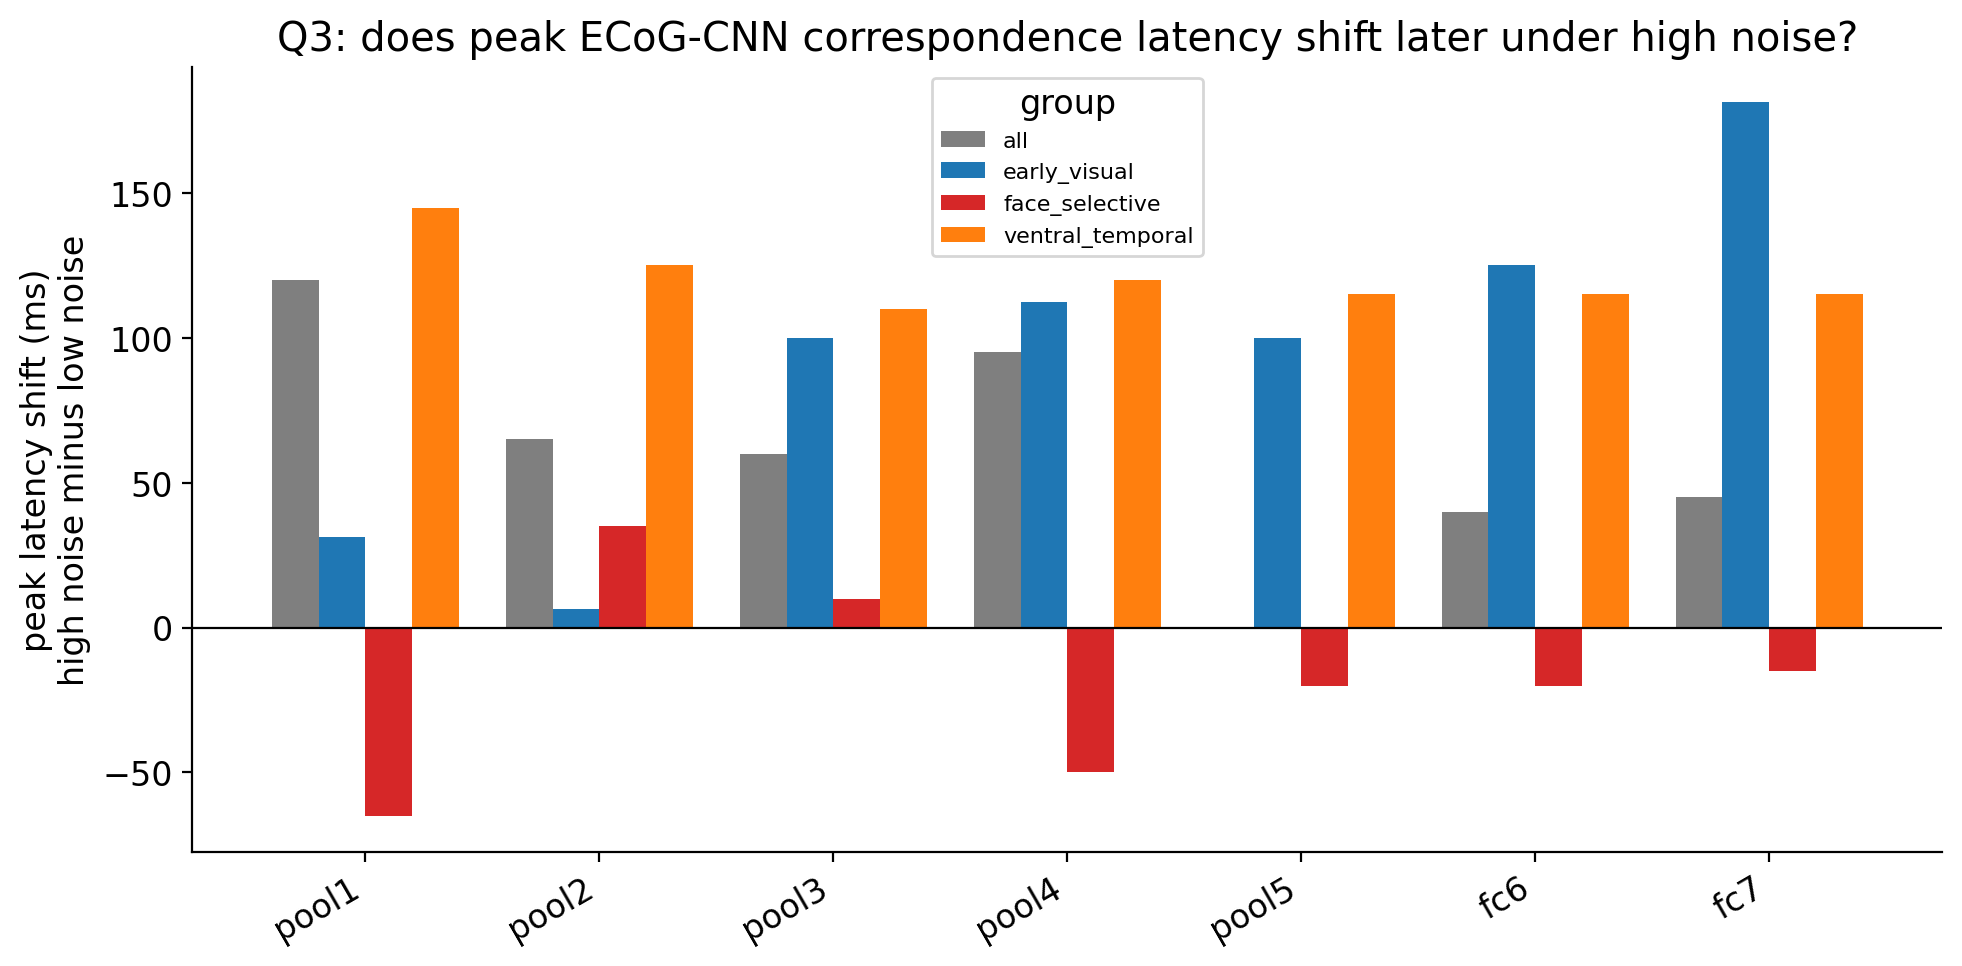

In [7]:
# @title Q3 -- time-resolved ECoG-CNN correspondence and peak-latency shift with noise

NOISE_SPLIT = {'low_noise': (0, 45), 'high_noise': (45, 101)}

def get_noise_range_indices(lo, hi, noise_levels=NOISE_LEVELS):
    levels = [n for n in noise_levels if lo <= n < hi]
    return [CONDITIONS.index(f'{cat}_{n}') for n in levels for cat in ['house', 'face']]

q3_rows = []
for s in usable:
    for group_name in GROUP_NAMES:
        for w_start in WIN_STARTS:
            ecog_rdm_t = build_group_rdm_windowed(s, group_name, w_start, w_start + WIN_WIDTH)
            if ecog_rdm_t is None:
                continue
            for L in layer_names:
                cnn_rdm = cnn_layer_rdms_primary[L]
                for split_name, (lo, hi) in NOISE_SPLIT.items():
                    idx = get_noise_range_indices(lo, hi)
                    r, p, n = compare_rdms(subset_rdm(ecog_rdm_t, idx), subset_rdm(cnn_rdm, idx))
                    q3_rows.append(dict(subject=s, group=group_name, layer=L,
                                         window_center=w_start + WIN_WIDTH // 2,
                                         noise_split=split_name, r=r, p=p, n_pairs=n))

q3_df = pd.DataFrame(q3_rows)
q3_df['layer'] = pd.Categorical(q3_df['layer'], categories=layer_names, ordered=True)
print(f"Built {len(q3_df)} rows; valid r: {q3_df['r'].notna().sum()}")

peak_rows = []
for (s, group_name, L, split_name), g in q3_df.groupby(['subject', 'group', 'layer', 'noise_split'], observed=True):
    g_valid = g.dropna(subset=['r'])
    if len(g_valid):
        peak_row = g_valid.loc[g_valid['r'].idxmax()]
        peak_rows.append(dict(subject=s, group=group_name, layer=L, noise_split=split_name,
                               peak_latency_ms=peak_row['window_center'], peak_r=peak_row['r']))
peak_df = pd.DataFrame(peak_rows)
peak_df['layer'] = pd.Categorical(peak_df['layer'], categories=layer_names, ordered=True)

latency_shift = peak_df.pivot_table(index=['group', 'layer'], columns='noise_split', values='peak_latency_ms', aggfunc=['mean', 'std'])
mean_lat = latency_shift['mean']; std_lat = latency_shift['std']
shift_ms = mean_lat['high_noise'] - mean_lat['low_noise']
print("\nPeak latency shift (high-noise minus low-noise), mean across subjects [ms]:")
print(shift_ms.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
groups_present = shift_ms.index.get_level_values('group').unique()
x = np.arange(len(layer_names)); width = 0.8 / max(len(groups_present), 1)
for i, group_name in enumerate(groups_present):
    vals = [shift_ms.loc[(group_name, L)] if (group_name, L) in shift_ms.index else np.nan for L in layer_names]
    ax.bar(x + i*width, vals, width, label=group_name, color=group_colors.get(group_name))
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + width*(len(groups_present)-1)/2); ax.set_xticklabels(layer_names, rotation=30, ha='right')
ax.set_ylabel('peak latency shift (ms)\nhigh noise minus low noise'); ax.legend(fontsize=8, title='group')
ax.set_title('Q3: does peak ECoG-CNN correspondence latency shift later under high noise?')
plt.tight_layout(); display(Image(save_fig(fig, '06_ecog_cnn_correspondence_fig05'))); plt.close(fig)


In [8]:
save_cache('06_ecog_cnn_correspondence', comparison_df=comparison_df, q2_df=q2_df)


Cached ['comparison_df', 'q2_df'] -> C:\Users\janak\GitHub\noisy-faces-brain-vs-cnn\cache\06_ecog_cnn_correspondence.pkl


'C:\\Users\\janak\\GitHub\\noisy-faces-brain-vs-cnn\\cache\\06_ecog_cnn_correspondence.pkl'